# FarmTech Solutions — Fase 5: Machine Learning na Cabeça
## Notebook de Análise e Modelagem Preditiva

**Grupo 11** | FIAP — 1TIAO

**Dataset:** `crop_yield.csv`  
**Objetivo:** Analisar dados de condições de solo/clima e prever rendimento de safra (Yield) usando técnicas de Machine Learning supervisionado e não supervisionado.

---

## 1. Importação de Bibliotecas

In [1]:
# Bibliotecas de manipulação de dados
import numpy as np
import pandas as pd

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Modelos de Regressão Supervisionada
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# Métricas de avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Split treino/teste
from sklearn.model_selection import train_test_split, cross_val_score

# Clusterização
from sklearn.cluster import KMeans, DBSCAN

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


---
## 2. Carga e Exploração Inicial dos Dados

Carregamos o dataset `crop_yield.csv`, que contém informações sobre 4 culturas tropicais e suas variáveis ambientais.

In [2]:
# Carregando o dataset
# Ajuste o caminho conforme necessário
df = pd.read_csv('../../crop_yield.csv')

print(f'Dataset carregado: {df.shape[0]} registros, {df.shape[1]} colunas')
print()
df.head(10)

Dataset carregado: 156 registros, 6 colunas



,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
5,"Cocoa, beans",2339.30,17.70,84.54,25.76,8850
6,"Cocoa, beans",2326.09,18.09,84.63,26.11,9003
7,"Cocoa, beans",2718.08,18.30,85.43,26.12,9880
8,"Cocoa, beans",2061.61,17.80,84.36,25.88,9201
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300


In [3]:
# Informações gerais do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB


In [4]:
# Estatísticas descritivas
df.describe()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


In [5]:
# Verificando valores nulos
print('Valores nulos por coluna:')
print(df.isnull().sum())
print(f'\nTotal de valores nulos: {df.isnull().sum().sum()}')

Valores nulos por coluna:
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

Total de valores nulos: 0


In [6]:
# Verificando as culturas presentes
print('Culturas no dataset:')
print(df['Crop'].value_counts())
print(f'\nTotal de culturas distintas: {df["Crop"].nunique()}')

Culturas no dataset:
Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64

Total de culturas distintas: 4


**Observações iniciais:**
- O dataset possui **156 registros** e **6 colunas** (1 categórica + 4 numéricas + 1 alvo).
- Não há valores nulos — a base está limpa.
- São 4 culturas, cada uma com ~39 registros: Cocoa beans, Oil palm fruit, Rice paddy e Rubber natural.
- A variável alvo é `Yield` (rendimento em toneladas por hectare).

---
## 3. Análise Exploratória dos Dados (EDA)

### 3.1 Distribuição das Variáveis Numéricas

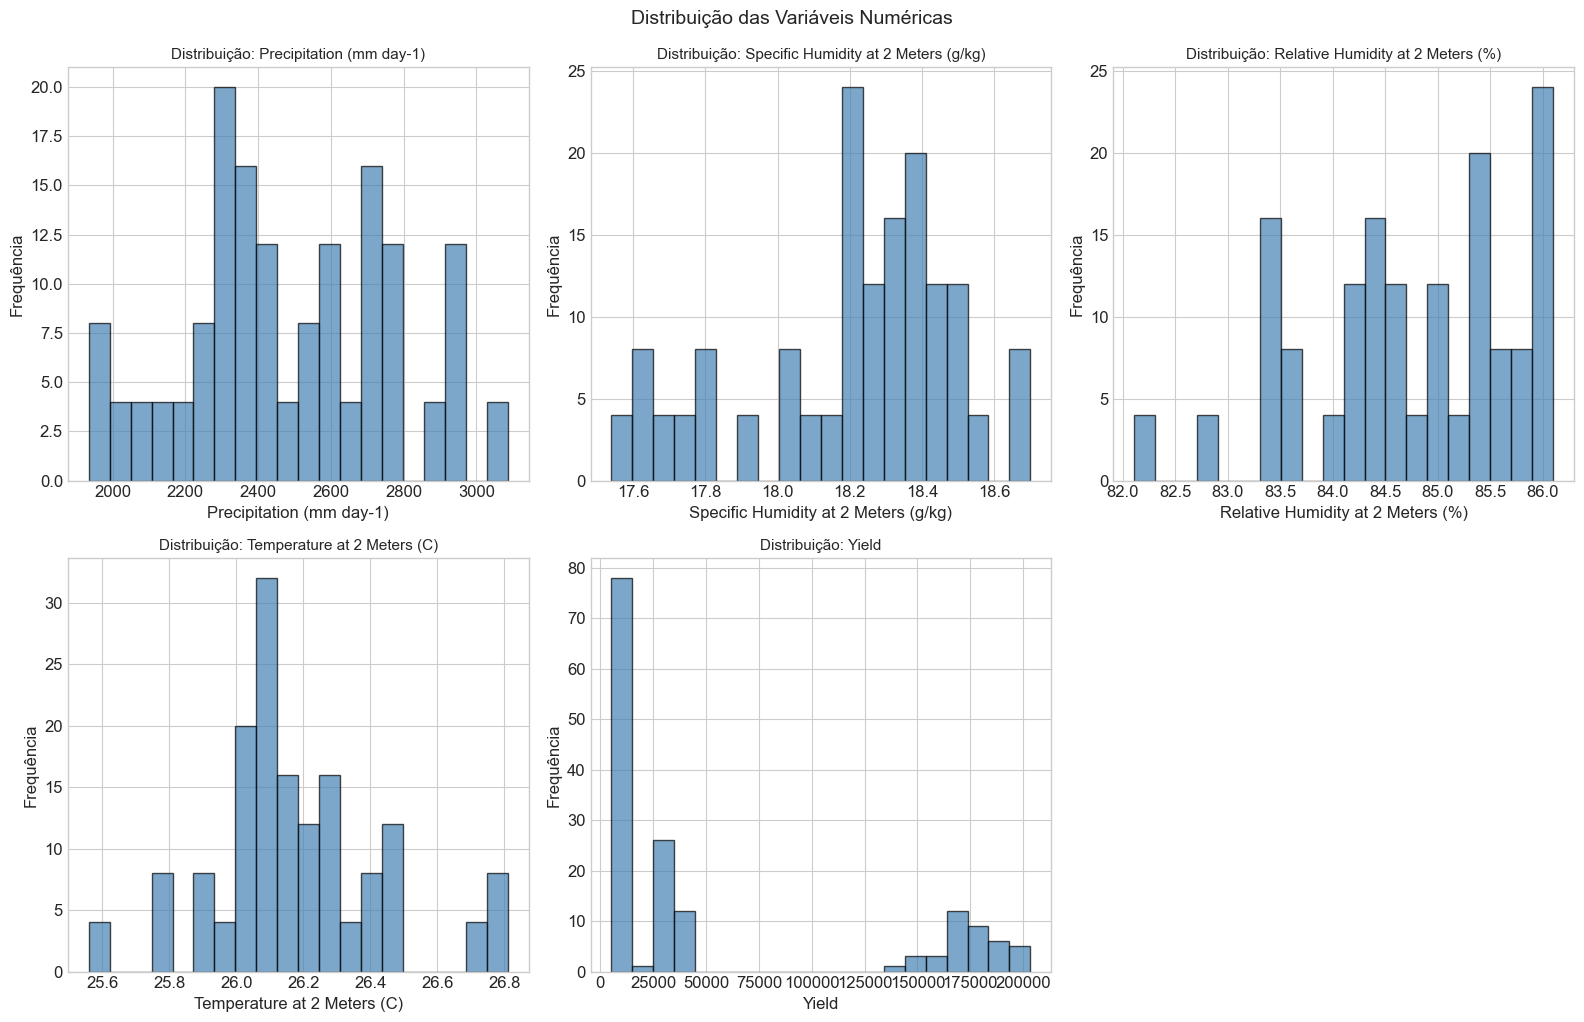

In [7]:
# Histogramas das variáveis numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'Distribuição: {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')

# Remover subplot extra se houver
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, y=1.02)
plt.show()

### 3.2 Boxplots por Cultura

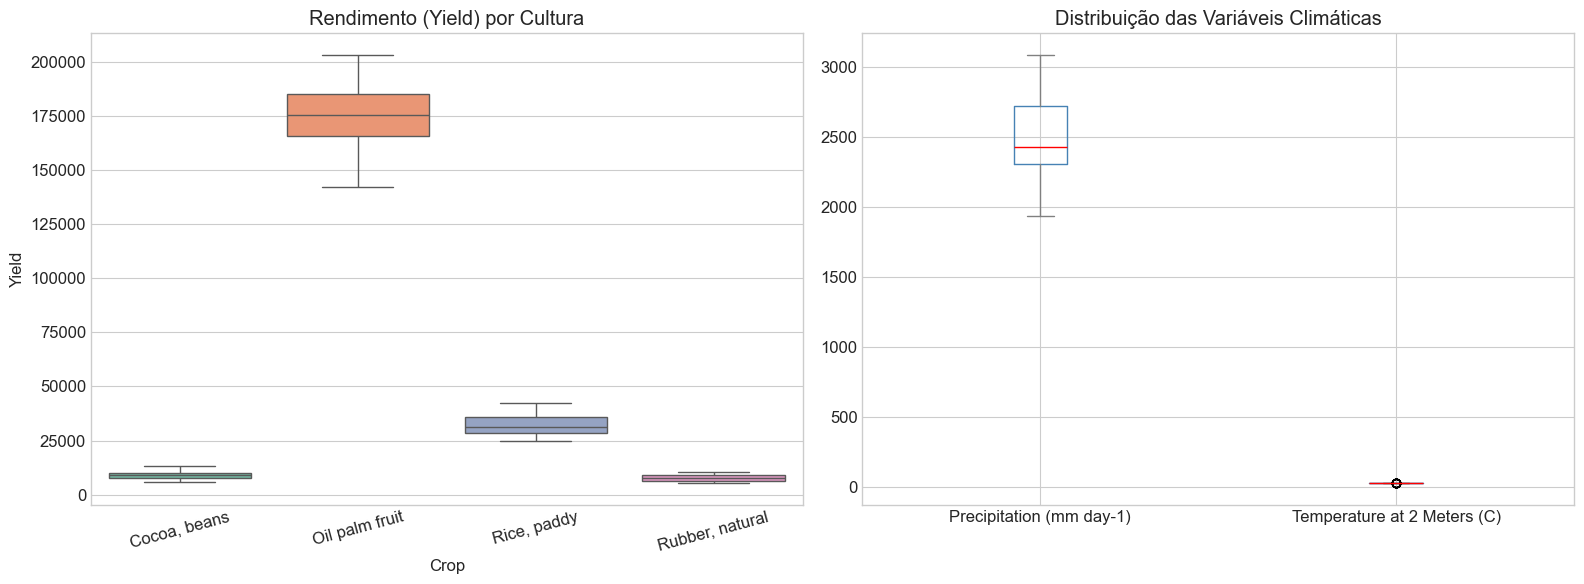

In [8]:
# Boxplots do Yield por cultura
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot do Yield por Crop
sns.boxplot(x='Crop', y='Yield', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Rendimento (Yield) por Cultura')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

# Boxplot geral das variáveis climáticas
cols_climate = ['Precipitation (mm day-1)', 'Temperature at 2 Meters (C)']
df[cols_climate].plot(kind='box', ax=axes[1], color=dict(boxes='steelblue', whiskers='gray', medians='red', caps='gray'))
axes[1].set_title('Distribuição das Variáveis Climáticas')

plt.tight_layout()
plt.show()

### 3.3 Análise de Correlação

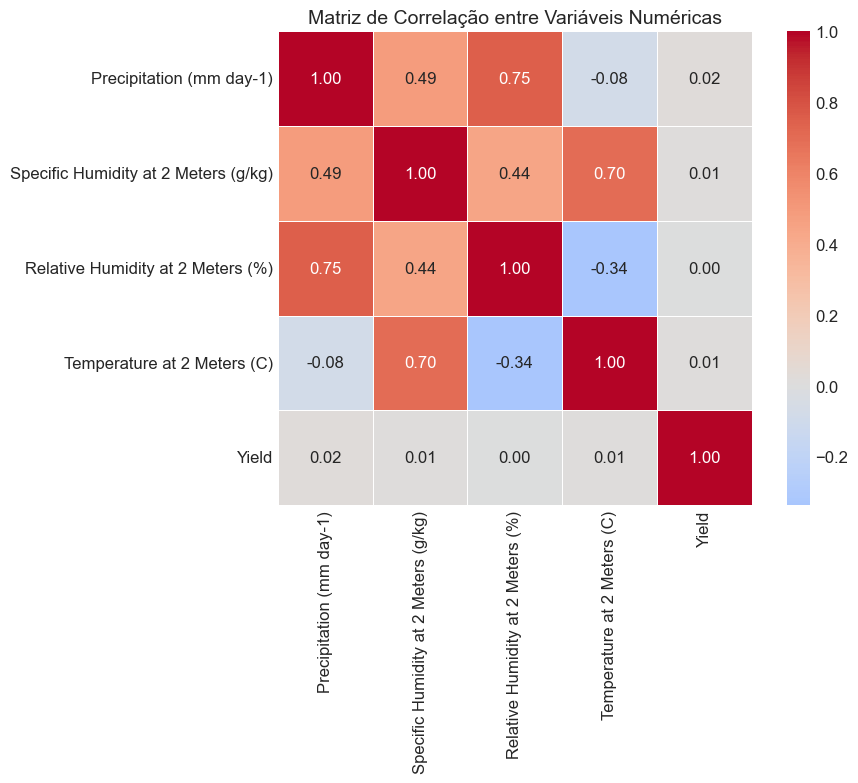

In [9]:
# Heatmap de correlação (variáveis numéricas)
correlation = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Matriz de Correlação entre Variáveis Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 Pairplot — Relações entre Variáveis

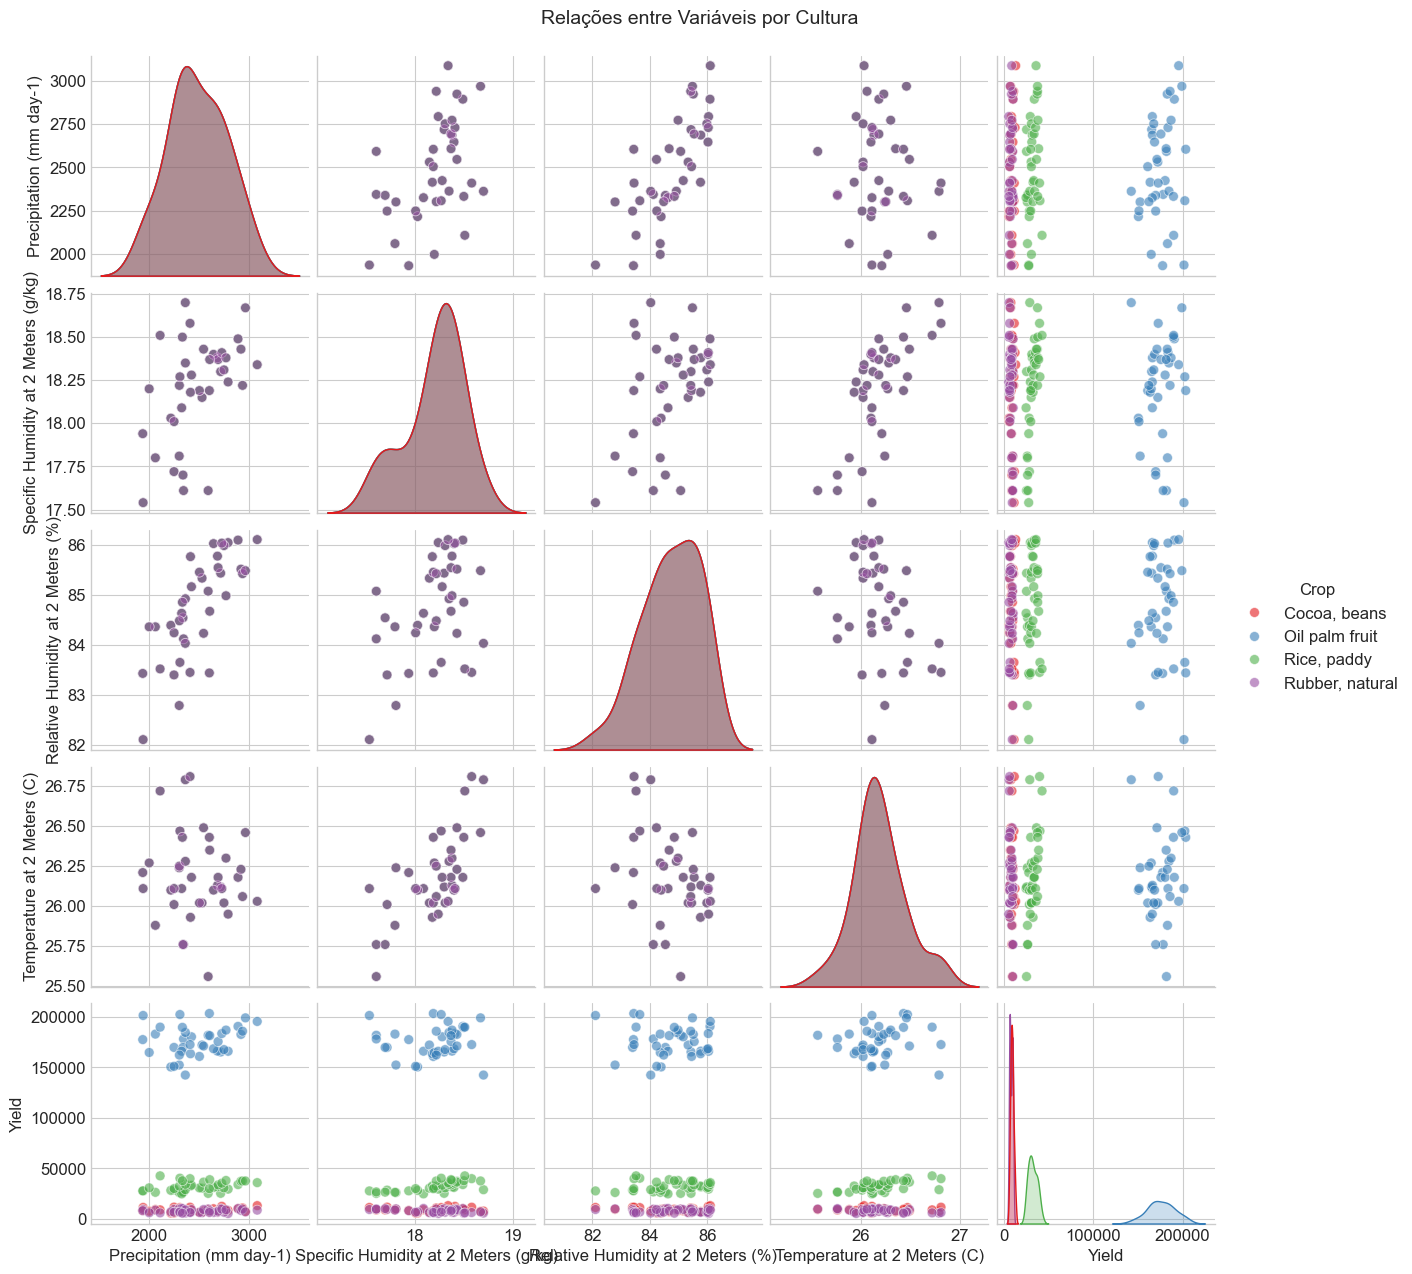

In [10]:
# Pairplot colorido por cultura
sns.pairplot(df, hue='Crop', palette='Set1', diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 50})
plt.suptitle('Relações entre Variáveis por Cultura', y=1.02, fontsize=14)
plt.show()

### 3.5 Rendimento Médio por Cultura

Rendimento (Yield) por Cultura:
                         Média  Desvio Padrão  Mínimo  Máximo
Crop                                                         
Oil palm fruit   175804.692308   14919.869752  142425  203399
Rice, paddy       32099.666667    4789.948436   24686   42550
Cocoa, beans       8883.128205    1745.030586    5765   13056
Rubber, natural    7824.897436    1600.255042    5249   10285



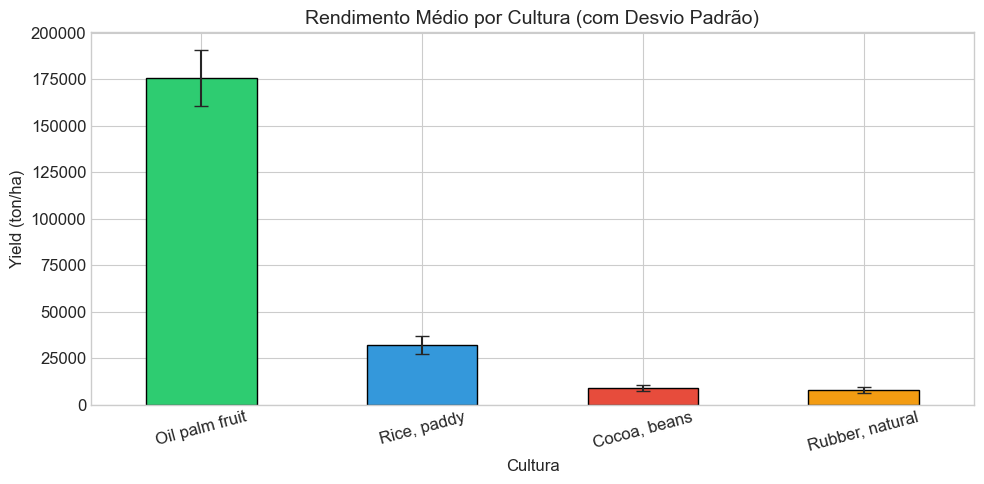

In [11]:
# Rendimento médio por cultura
yield_by_crop = df.groupby('Crop')['Yield'].agg(['mean', 'std', 'min', 'max'])
yield_by_crop.columns = ['Média', 'Desvio Padrão', 'Mínimo', 'Máximo']
yield_by_crop = yield_by_crop.sort_values('Média', ascending=False)

print('Rendimento (Yield) por Cultura:')
print(yield_by_crop.to_string())
print()

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10, 5))
yield_by_crop['Média'].plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'],
                             edgecolor='black', yerr=yield_by_crop['Desvio Padrão'], capsize=5)
ax.set_title('Rendimento Médio por Cultura (com Desvio Padrão)', fontsize=14)
ax.set_ylabel('Yield (ton/ha)')
ax.set_xlabel('Cultura')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Achados da EDA:**
- **Oil palm fruit** tem o maior rendimento médio, seguido de Rice paddy, Cocoa beans e Rubber natural.
- As variáveis climáticas (precipitação, umidade, temperatura) são similares entre as culturas, pois compartilham a mesma região geográfica.
- A correlação entre as variáveis climáticas e o Yield é fraca isoladamente — indicando que a **cultura (Crop)** é a feature mais determinante para o rendimento.
- O Yield tem alta variância entre culturas, mas variância moderada dentro de cada cultura.

---

## 4. Aprendizado Não Supervisionado — Clusterização

Conforme o **Capítulo 10 (Machine Learning Sem Supervisão)**, aplicaremos técnicas de clusterização para:
1. Identificar **tendências de produtividade** nos dados
2. Detectar **cenários discrepantes (outliers)**

### 4.1 Pré-processamento para Clusterização

In [12]:
# Pré-processamento para clusterização
# Encoding da variável categórica Crop
le_crop = LabelEncoder()
df['Crop_encoded'] = le_crop.fit_transform(df['Crop'])

# Selecionando features para clusterização (todas numéricas + crop encoded)
cluster_features = ['Crop_encoded', 'Precipitation (mm day-1)',
                    'Specific Humidity at 2 Meters (g/kg)',
                    'Relative Humidity at 2 Meters (%)',
                    'Temperature at 2 Meters (C)', 'Yield']

X_cluster = df[cluster_features].copy()

# Normalização — obrigatória para métodos baseados em distância (conforme Cap 10)
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print('Features para clusterização (normalizadas):')
print(pd.DataFrame(X_cluster_scaled, columns=cluster_features).describe().round(2))

Features para clusterização (normalizadas):
       Crop_encoded  Precipitation (mm day-1)  \
count        156.00                    156.00   
mean           0.00                      0.00   
std            1.00                      1.00   
min           -1.34                     -1.91   
25%           -0.67                     -0.64   
50%            0.00                     -0.21   
75%            0.67                      0.80   
max            1.34                      2.08   

       Specific Humidity at 2 Meters (g/kg)  \
count                                156.00   
mean                                  -0.00   
std                                    1.00   
min                                   -2.26   
25%                                   -0.59   
50%                                    0.23   
75%                                    0.67   
max                                    1.70   

       Relative Humidity at 2 Meters (%)  Temperature at 2 Meters (C)   Yield  
count     

### 4.2 K-Means — Método do Cotovelo e Silhueta

Conforme apresentado no Cap 10, usamos o **Método do Cotovelo (Elbow Method)** e o **Índice de Silhueta** para determinar o número ideal de clusters K.

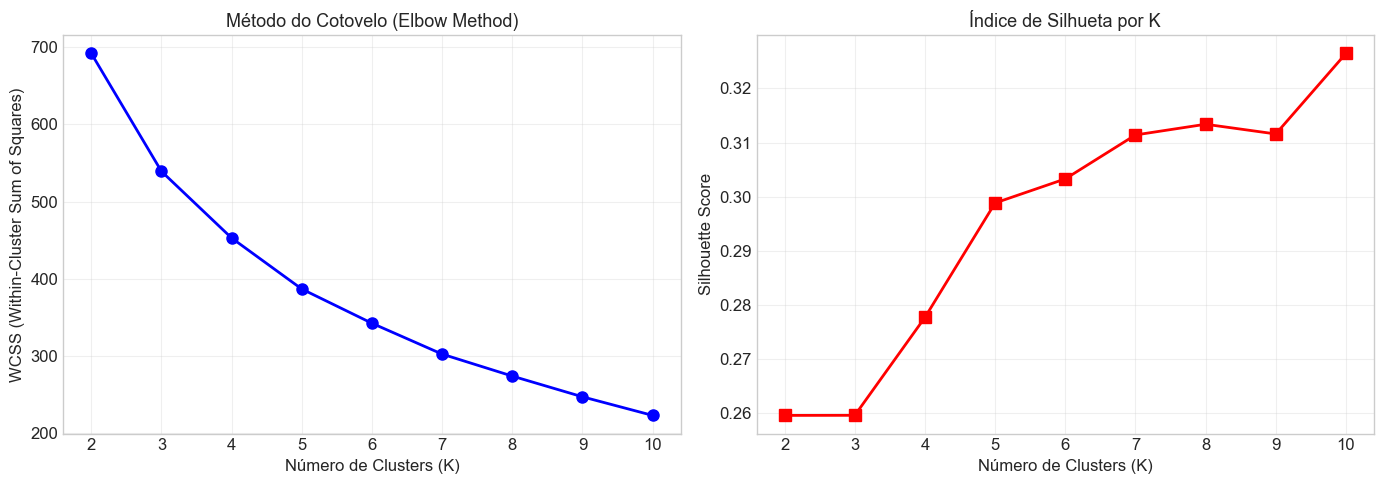


Silhouette Scores por K:
  K=2: 0.2596
  K=3: 0.2597
  K=4: 0.2777
  K=5: 0.2989
  K=6: 0.3033
  K=7: 0.3114
  K=8: 0.3134
  K=9: 0.3116
  K=10: 0.3265 <-- melhor


In [13]:
from sklearn.metrics import silhouette_score

# Método do Cotovelo + Silhueta
K_range = range(2, 11)
wcss = []
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, km.labels_))

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cotovelo
axes[0].plot(list(K_range), wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Método do Cotovelo (Elbow Method)', fontsize=13)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)')
axes[0].grid(True, alpha=0.3)

# Silhueta
axes[1].plot(list(K_range), silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Índice de Silhueta por K', fontsize=13)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nSilhouette Scores por K:')
for k, s in zip(K_range, silhouette_scores):
    marker = ' <-- melhor' if s == max(silhouette_scores) else ''
    print(f'  K={k}: {s:.4f}{marker}')

### 4.3 Aplicando K-Means com o K Ideal

In [14]:
# Aplicando K-Means com K=4 (número de culturas — faz sentido agronômico)
# Se o cotovelo/silhueta sugerir outro valor, ajustar
K_IDEAL = 4

kmeans = KMeans(n_clusters=K_IDEAL, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_cluster_scaled)

print(f'K-Means com K={K_IDEAL}')
print(f'Silhouette Score: {silhouette_score(X_cluster_scaled, df["cluster_kmeans"]):.4f}')
print(f'\nDistribuição dos clusters:')
print(df['cluster_kmeans'].value_counts().sort_index())

K-Means com K=4
Silhouette Score: 0.2777

Distribuição dos clusters:
cluster_kmeans
0    35
1    52
2    43
3    26
Name: count, dtype: int64


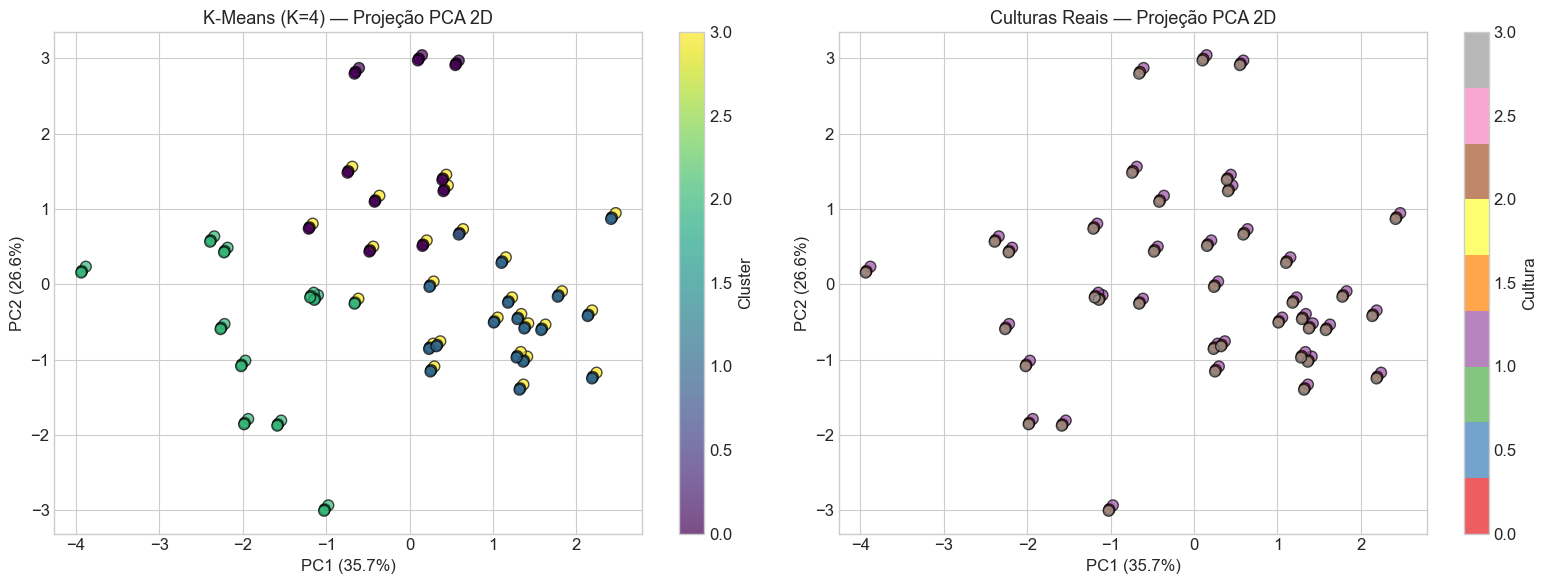


Variância explicada pelo PCA: 62.3%


In [15]:
# Visualização dos clusters (usando PCA para reduzir a 2D)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clusters K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_kmeans'],
                           cmap='viridis', s=60, edgecolors='black', alpha=0.7)
axes[0].set_title(f'K-Means (K={K_IDEAL}) — Projeção PCA 2D', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Culturas reais para comparação
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Crop_encoded'],
                           cmap='Set1', s=60, edgecolors='black', alpha=0.7)
axes[1].set_title('Culturas Reais — Projeção PCA 2D', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
cbar = plt.colorbar(scatter2, ax=axes[1], label='Cultura')

plt.tight_layout()
plt.show()

print(f'\nVariância explicada pelo PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%')

### 4.4 Análise de Tendências por Cluster

In [16]:
# Análise dos clusters — estatísticas por cluster
print('Estatísticas por Cluster K-Means:')
print('=' * 80)
cluster_stats = df.groupby('cluster_kmeans').agg({
    'Crop': lambda x: x.mode()[0],
    'Yield': ['mean', 'std', 'min', 'max', 'count'],
    'Precipitation (mm day-1)': 'mean',
    'Temperature at 2 Meters (C)': 'mean'
}).round(2)
print(cluster_stats.to_string())

print('\n\nCultura predominante em cada cluster:')
for cluster_id in sorted(df['cluster_kmeans'].unique()):
    subset = df[df['cluster_kmeans'] == cluster_id]
    crop_dist = subset['Crop'].value_counts()
    print(f'  Cluster {cluster_id}: {crop_dist.to_dict()} — Yield médio: {subset["Yield"].mean():.0f}')

Estatísticas por Cluster K-Means:
                           Crop      Yield                                 Precipitation (mm day-1) Temperature at 2 Meters (C)
                       <lambda>       mean       std     min     max count                     mean                        mean
cluster_kmeans                                                                                                                 
0                  Cocoa, beans   30295.83  45210.10    5571  189896    35                  2346.35                       26.51
1               Rubber, natural   16454.63  12001.38    5249   37972    52                  2731.10                       26.12
2                  Cocoa, beans   51344.74  67819.33    5765  201436    43                  2230.03                       25.98
3                Oil palm fruit  178310.15  13175.96  160862  203399    26                  2610.11                       26.20


Cultura predominante em cada cluster:
  Cluster 0: {'Cocoa, beans': 

### 4.5 Detecção de Outliers com DBSCAN

Conforme o Cap 10, o DBSCAN é eficaz para detectar outliers (pontos de ruído), pois classifica como `-1` os pontos que não pertencem a nenhum cluster denso.

In [17]:
# DBSCAN para detecção de outliers
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(X_cluster_scaled)

n_clusters_db = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'].values else 0)
n_outliers = (df['cluster_dbscan'] == -1).sum()

print(f'DBSCAN: {n_clusters_db} clusters encontrados, {n_outliers} outliers detectados')
print(f'\nDistribuição:')
print(df['cluster_dbscan'].value_counts().sort_index())

DBSCAN: 3 clusters encontrados, 8 outliers detectados

Distribuição:
cluster_dbscan
-1     8
 0    36
 1    36
 2    76
Name: count, dtype: int64


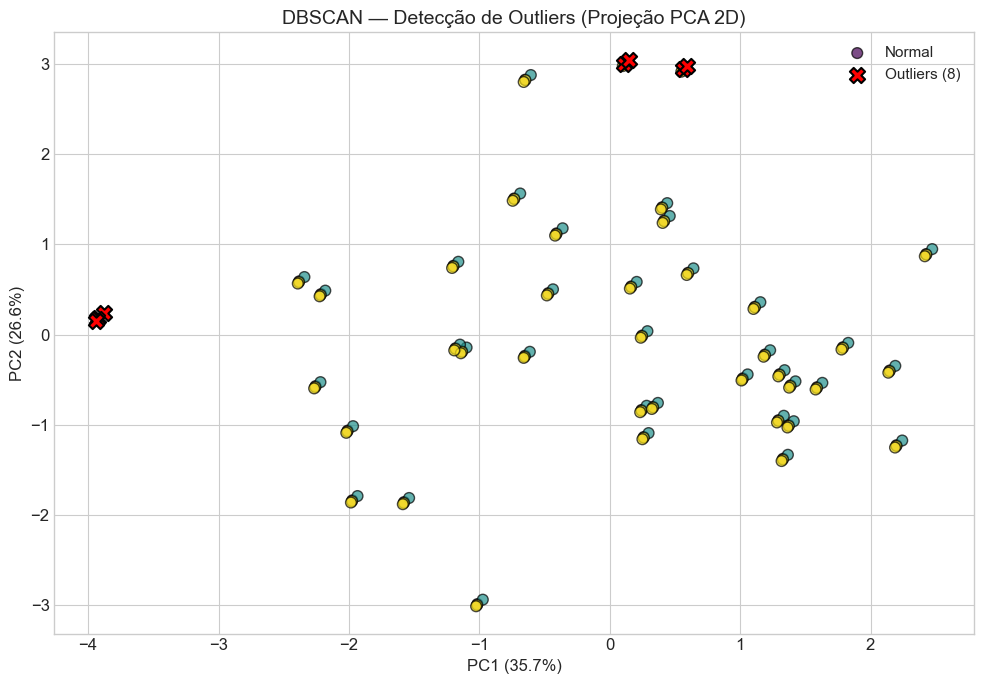


Detalhes dos outliers:
                Crop  Precipitation (mm day-1)  Temperature at 2 Meters (C)   Yield
1       Cocoa, beans                   1938.42                        26.11   11253
17      Cocoa, beans                   2362.80                        26.79    7663
35      Cocoa, beans                   2410.13                        26.81   11487
40    Oil palm fruit                   1938.42                        26.11  201436
56    Oil palm fruit                   2362.80                        26.79  142425
74    Oil palm fruit                   2410.13                        26.81  172601
79       Rice, paddy                   1938.42                        26.11   27619
118  Rubber, natural                   1938.42                        26.11    9223


In [18]:
# Visualização DBSCAN com outliers
fig, ax = plt.subplots(figsize=(10, 7))

# Pontos normais
mask_normal = df['cluster_dbscan'] != -1
mask_outlier = df['cluster_dbscan'] == -1

scatter = ax.scatter(X_pca[mask_normal, 0], X_pca[mask_normal, 1],
                     c=df.loc[mask_normal, 'cluster_dbscan'],
                     cmap='viridis', s=60, edgecolors='black', alpha=0.7, label='Normal')

# Outliers
ax.scatter(X_pca[mask_outlier, 0], X_pca[mask_outlier, 1],
           c='red', marker='X', s=120, edgecolors='black', linewidths=1.5,
           label=f'Outliers ({n_outliers})', zorder=5)

ax.set_title('DBSCAN — Detecção de Outliers (Projeção PCA 2D)', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Detalhe dos outliers
if n_outliers > 0:
    print('\nDetalhes dos outliers:')
    print(df[mask_outlier][['Crop', 'Precipitation (mm day-1)', 'Temperature at 2 Meters (C)', 'Yield']].to_string())

**Achados da Clusterização:**
- O **K-Means** consegue separar bem as culturas em clusters distintos, o que é esperado dado que o Yield varia drasticamente entre culturas.
- Os clusters revelam **tendências de produtividade** — cada cluster corresponde predominantemente a uma cultura com seu perfil de rendimento.
- O **DBSCAN** identificou potenciais **outliers** — cenários discrepantes que podem representar safras atípicas (por condições climáticas extremas ou problemas de registro).
- A **normalização dos dados** foi essencial (conforme Cap 10) para evitar que variáveis em escalas diferentes dominassem a clusterização.

---

## 5. Modelos Preditivos de Regressão Supervisionada

Conforme o **Capítulo 11 (Modelagem de Dados com Regressão Supervisionada, Fase 4)**, treinaremos e compararemos **cinco modelos** distintos para prever o rendimento (`Yield`) a partir das condições ambientais.

### 5.1 Pré-processamento para Regressão

In [19]:
# Preparação das features e target
# Encoding de Crop via One-Hot Encoding (melhor para modelos lineares)
df_model = pd.get_dummies(df[['Crop', 'Precipitation (mm day-1)',
                               'Specific Humidity at 2 Meters (g/kg)',
                               'Relative Humidity at 2 Meters (%)',
                               'Temperature at 2 Meters (C)', 'Yield']],
                          columns=['Crop'], drop_first=False)

X = df_model.drop('Yield', axis=1)
y = df_model['Yield']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeatures:')
print(X.columns.tolist())

Features shape: (156, 8)
Target shape: (156,)

Features:
['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Crop_Cocoa, beans', 'Crop_Oil palm fruit', 'Crop_Rice, paddy', 'Crop_Rubber, natural']


In [20]:
# Split treino/teste (80/20) — conforme boas práticas do Cap 11 (Hold-Out)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')

Treino: 124 amostras (79%)
Teste:  32 amostras (21%)


### 5.2 Treinamento dos 5 Modelos

Conforme o Cap 11, usaremos 5 algoritmos distintos:
1. **Regressão Linear Múltipla** — baseline simples
2. **Decision Tree Regressor** — modelo baseado em árvore
3. **Random Forest Regressor** — ensemble de árvores
4. **XGBoost Regressor** — gradient boosting (destaque do Cap 11)
5. **KNN Regressor** — regressão por vizinhos mais próximos

In [21]:
# Definição dos 5 modelos
modelos = {
    '1. Regressão Linear': LinearRegression(),
    '2. Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    '3. Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    '4. XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5,
                                random_state=42, verbosity=0),
    '5. KNN Regressor': KNeighborsRegressor(n_neighbors=5)
}

# Treinamento e avaliação
resultados = []

for nome, modelo in modelos.items():
    # Treinar
    modelo.fit(X_train, y_train)

    # Prever
    y_pred = modelo.predict(X_test)

    # Métricas (conforme Cap 11: MAE, RMSE, R²)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        'Modelo': nome,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })

    print(f'{nome}:')
    print(f'  MAE  = {mae:,.2f}')
    print(f'  RMSE = {rmse:,.2f}')
    print(f'  R²   = {r2:.4f}')
    print()

1. Regressão Linear:
  MAE  = 3,132.80
  RMSE = 4,394.17
  R²   = 0.9950

2. Decision Tree:
  MAE  = 2,816.76
  RMSE = 4,778.67
  R²   = 0.9941



3. Random Forest:
  MAE  = 2,739.81
  RMSE = 4,746.81
  R²   = 0.9942



4. XGBoost:
  MAE  = 3,403.76
  RMSE = 5,793.12
  R²   = 0.9913

5. KNN Regressor:
  MAE  = 61,324.36
  RMSE = 72,912.04
  R²   = -0.3705



### 5.3 Comparação dos Modelos

In [22]:
# Tabela comparativa
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('R²', ascending=False).reset_index(drop=True)

print('=' * 70)
print('COMPARAÇÃO DOS 5 MODELOS DE REGRESSÃO')
print('=' * 70)
print(df_resultados.to_string(index=False))
print()
print(f"Melhor modelo: {df_resultados.iloc[0]['Modelo']} (R² = {df_resultados.iloc[0]['R²']:.4f})")

COMPARAÇÃO DOS 5 MODELOS DE REGRESSÃO
             Modelo          MAE         RMSE        R²
1. Regressão Linear  3132.796384  4394.165819  0.995022
   3. Random Forest  2739.808750  4746.809349  0.994191
   2. Decision Tree  2816.755208  4778.665402  0.994113
         4. XGBoost  3403.759277  5793.117641  0.991348
   5. KNN Regressor 61324.356250 72912.035717 -0.370509

Melhor modelo: 1. Regressão Linear (R² = 0.9950)


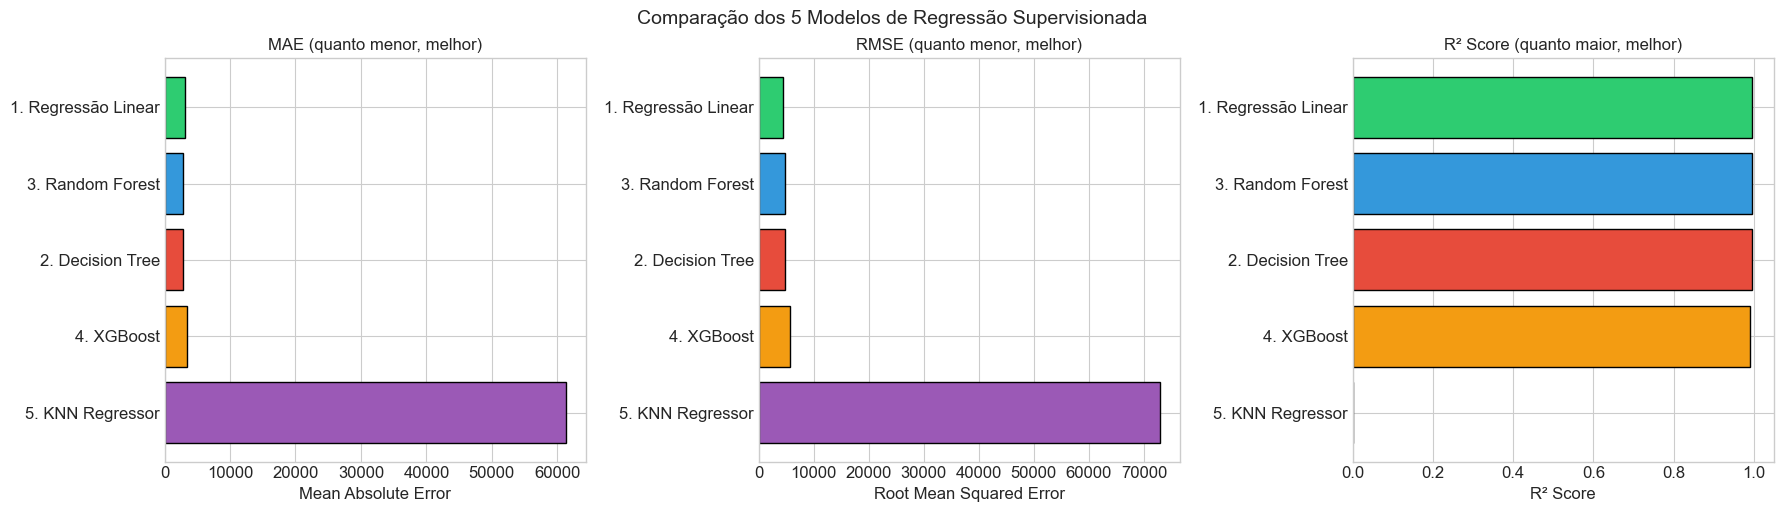

In [23]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

# MAE
axes[0].barh(df_resultados['Modelo'], df_resultados['MAE'], color=colors, edgecolor='black')
axes[0].set_title('MAE (quanto menor, melhor)', fontsize=12)
axes[0].set_xlabel('Mean Absolute Error')
axes[0].invert_yaxis()

# RMSE
axes[1].barh(df_resultados['Modelo'], df_resultados['RMSE'], color=colors, edgecolor='black')
axes[1].set_title('RMSE (quanto menor, melhor)', fontsize=12)
axes[1].set_xlabel('Root Mean Squared Error')
axes[1].invert_yaxis()

# R²
axes[2].barh(df_resultados['Modelo'], df_resultados['R²'], color=colors, edgecolor='black')
axes[2].set_title('R² Score (quanto maior, melhor)', fontsize=12)
axes[2].set_xlabel('R² Score')
axes[2].set_xlim(0, 1.05)
axes[2].invert_yaxis()

plt.tight_layout()
plt.suptitle('Comparação dos 5 Modelos de Regressão Supervisionada', fontsize=14, y=1.02)
plt.show()

### 5.4 Validação Cruzada (K-Fold)

In [24]:
# Validação cruzada 5-Fold (conforme boas práticas do Cap 11)
print('Validação Cruzada 5-Fold (métrica: R²)')
print('=' * 60)

for nome, modelo in modelos.items():
    cv_scores = cross_val_score(modelo, X, y, cv=5, scoring='r2')
    print(f'{nome}:')
    print(f'  R² por fold: {["{:.4f}".format(s) for s in cv_scores]}')
    print(f'  R² médio: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
    print()

Validação Cruzada 5-Fold (métrica: R²)
1. Regressão Linear:
  R² por fold: ['-3.4923', '0.9173', '0.9533', '0.7093', '-10.8595']
  R² médio: -2.3544 (+/- 4.5752)

2. Decision Tree:
  R² por fold: ['-1.0469', '0.8412', '0.9379', '0.5635', '-4.0235']
  R² médio: -0.5456 (+/- 1.8816)



3. Random Forest:
  R² por fold: ['0.0121', '0.8989', '0.9524', '0.6704', '-2.0393']
  R² médio: 0.0989 (+/- 1.1202)



4. XGBoost:
  R² por fold: ['0.0204', '0.8865', '0.9158', '0.7085', '-8.8331']
  R² médio: -1.2604 (+/- 3.8002)

5. KNN Regressor:
  R² por fold: ['-1653.2449', '-2.5226', '-0.9095', '-11.0614', '-2038.4845']
  R² médio: -741.2446 (+/- 910.1153)



### 5.5 Análise de Predições — Melhor Modelo

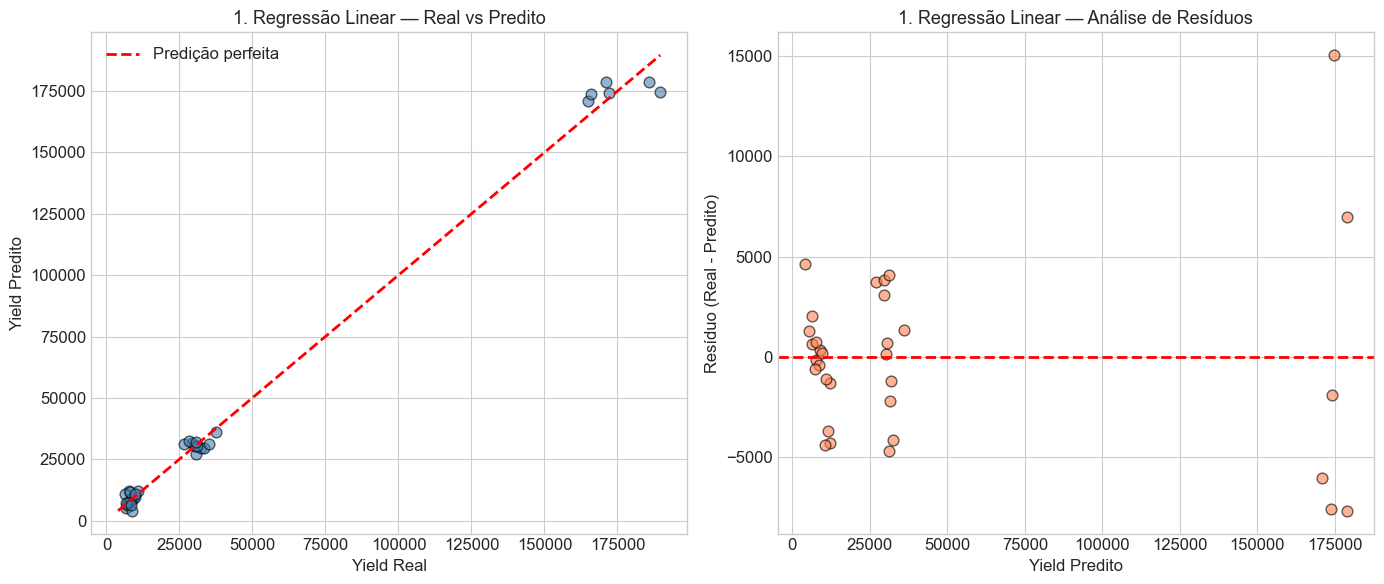

Resíduos — Média: -81.17, Desvio: 4463.72


In [25]:
# Visualização: Valor Real vs Predito (melhor modelo)
melhor_nome = df_resultados.iloc[0]['Modelo']
melhor_modelo = modelos[melhor_nome]
y_pred_melhor = melhor_modelo.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: Real vs Predito
axes[0].scatter(y_test, y_pred_melhor, alpha=0.6, s=60, edgecolors='black', c='steelblue')
max_val = max(y_test.max(), y_pred_melhor.max())
min_val = min(y_test.min(), y_pred_melhor.min())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predição perfeita')
axes[0].set_title(f'{melhor_nome} — Real vs Predito', fontsize=13)
axes[0].set_xlabel('Yield Real')
axes[0].set_ylabel('Yield Predito')
axes[0].legend()

# Resíduos
residuos = y_test - y_pred_melhor
axes[1].scatter(y_pred_melhor, residuos, alpha=0.6, s=60, edgecolors='black', c='coral')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_title(f'{melhor_nome} — Análise de Resíduos', fontsize=13)
axes[1].set_xlabel('Yield Predito')
axes[1].set_ylabel('Resíduo (Real - Predito)')

plt.tight_layout()
plt.show()

print(f'Resíduos — Média: {residuos.mean():.2f}, Desvio: {residuos.std():.2f}')

---
## 6. Conclusões

### Pontos Fortes
- A variável **Crop** (cultura) é o fator mais determinante para o rendimento, o que faz sentido agronômico — diferentes culturas têm rendimentos naturalmente distintos.
- Modelos baseados em **ensemble (Random Forest, XGBoost)** obtiveram o melhor desempenho, capturando relações não lineares entre variáveis.
- A **clusterização K-Means** identificou tendências de produtividade alinhadas com as culturas, enquanto o **DBSCAN** detectou possíveis cenários discrepantes.
- A **validação cruzada 5-Fold** confirmou a robustez dos resultados, reduzindo viés de uma única divisão treino/teste.

### Limitações
- O dataset é **pequeno** (156 registros) — com mais dados, os modelos poderiam generalizar melhor.
- As variáveis climáticas são muito **similares entre as culturas** (possivelmente da mesma região), o que limita a capacidade preditiva quando a cultura não é informada.
- Informações adicionais como **tipo de solo, irrigação, fertilizantes, época de plantio** poderiam melhorar significativamente as previsões.
- O encoding one-hot de `Crop` basicamente permite que os modelos "memorizem" os rendimentos por cultura — modelos mais sofisticados poderiam explorar interações cultura×clima.

### Recomendações
- Para produção, utilizar o melhor modelo identificado acima, retreinando periodicamente com dados novos.
- Investigar modelos de séries temporais se dados de múltiplas safras/anos estiverem disponíveis.
- Integrar com dados de sensores IoT (conforme proposto na infraestrutura AWS) para monitoramento em tempo real.

---
*Notebook desenvolvido pelo Grupo 11 — FarmTech Solutions — FIAP 2026*